# Con đường phục hồi lợi nhuận

Waterfall chart theo phong cách executive consulting, mô phỏng cách doanh nghiệp có thể thu hẹp khoảng hụt lợi nhuận thông qua nhiều đòn bẩy chiến lược phối hợp.

**Lưu ý:** Các giá trị trong biểu đồ là chỉ số minh họa để phục vụ storytelling và prescriptive analytics. Đây không phải số liệu kế toán hay forecast output từ model.

In [140]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

In [141]:
def configure_font():
    candidates = [
        Path("C:/Windows/Fonts/arial.ttf"),
        Path("C:/Windows/Fonts/segoeui.ttf"),
        Path("C:/Windows/Fonts/calibri.ttf"),
    ]
    for path in candidates:
        if path.exists():
            font_manager.fontManager.addfont(str(path))
            plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(path)).get_name()
            return
    plt.rcParams["font.family"] = "Times New Roman"  # Fallback to a common font


def resolve_output_dir():
    cwd = Path.cwd()
    if cwd.name == "report_visuals":
        return cwd
    candidate = cwd / "ai_eda" / "report_visuals"
    if candidate.exists():
        return candidate
    return cwd


configure_font()
OUT_DIR = resolve_output_dir()
OUT_DIR

WindowsPath('d:/Datathon-2026-Inlier/ai_eda/report_visuals')

In [142]:
labels = [
    'Khoảng hụt\nLợi nhuận',
    'Loại bỏ\nFixed Promo',
    'Tối ưu\nSize Guide',
    'Xả lỗ danh mục\nOutdoor',
    'Tái đầu tư\nStreetwear',
    'Khoảng hụt\ncòn lại', # Đổi label để khớp với Visual
]

# Giá trị âm (-15) tại Outdoor chính là phần Trade-off (Đánh đổi).
contributions = [-100, 40, 15, -15, 40]
final_value = sum(contributions)
values = contributions + [final_value]

colors = {
    "start": "#566B5F",
    "lever_pos": "#8FB79C", 
    "lever_neg": "#E11D48", 
    "final": "#123D2A",
    "connector": "#688D72",
    "grid": "#E7ECE8",
    "text": "#1E2A23",
    "muted": "#19321F",
}

In [143]:
def create_profit_recovery_waterfall(labels, values, contributions, final_value, colors):
    fig, ax = plt.subplots(figsize=(15.8, 8.2), dpi=180) # Giảm chiều cao hình xuống một chút để siết khoảng trắng
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    x = np.arange(len(labels))
    bar_w = 0.62
    cum = 0
    bottoms, heights, end_levels = [], [], []

    for i, val in enumerate(values):
        if i == 0:
            bottom, height, cum = 0, val, val
        elif i == len(values) - 1:
            bottom, height = 0, final_value
        else:
            bottom, height, cum = cum, val, cum + val
            
        bottoms.append(bottom)
        heights.append(height)
        end_levels.append(bottom + height)

    for i, (bottom, height) in enumerate(zip(bottoms, heights)):
        if i == 0:
            color = colors["start"]
        elif i == len(values) - 1:
            color = colors["final"]
        elif height < 0:
            color = colors["lever_neg"]
        else:
            color = colors["lever_pos"]
            
        ax.bar(
            x[i], height, bottom=bottom, width=bar_w,
            color=color, edgecolor="white", linewidth=1.4, zorder=3,
        )

    for i in range(len(values) - 1):
        level = end_levels[i]
        ax.plot(
            [x[i] + bar_w / 2, x[i + 1] - bar_w / 2], [level, level],
            color=colors["connector"], lw=1.2, zorder=2,
        )

    ax.axhline(0, color="#B9C2BB", lw=1.1, zorder=1)

    for i, (bottom, height) in enumerate(zip(bottoms, heights)):
        if i == 0:
            ax.text(x[i], bottom + height / 2, "-100", ha="center", va="center", fontsize=12, fontweight="bold", color="white")
        elif i == len(values) - 1:
            # FIX 1: Chữ hiển thị đúng logic toán học và trực quan
            ax.text(x[i], final_value - 4, f"{final_value:.0f}", ha="center", va="top", fontsize=13, fontweight="bold", color=colors["final"])
            ax.text(x[i], final_value - 10, "Đã phục hồi\n~80%", ha="center", va="top", fontsize=12, color=colors["final"], fontweight="bold")
        else:
            if height >= 0:
                y_pos, va_align, text_str = bottom + height + 3, "bottom", f"+{height:.0f}"
            else:
                y_pos, va_align, text_str = bottom + height - 3, "top", f"{height:.0f}"
                
            ax.text(x[i], y_pos, text_str, ha="center", va=va_align, fontsize=12, fontweight="bold", color=colors["text"])

    ax.text(2.5, 30, "CÁC ĐÒN BẨY CHIẾN LƯỢC TỐI ƯU & ĐÁNH ĐỔI", fontsize=15, color=colors["muted"], fontweight="bold", ha="center", va="center")
    ax.plot([0.65, 4.35], [26, 26], color=colors["grid"], lw=1.5)

    # FIX 4 & FIX 5: Annotation ngắn lại, wording sắc bén mang tính Business hơn
    ax.annotate(
        "Chấm dứt Fixed Promo,\nkhôi phục biên lợi nhuận",
        xy=(1, -80), xycoords="data", xytext=(1.5, -75), textcoords="data",
        arrowprops=dict(arrowstyle="-", color=colors["connector"], lw=1.2),
        fontsize=11, color=colors["muted"], ha="left", va="center",
    )
    ax.annotate(
        "Chấp nhận hy sinh Margin\nđể xả hàng, giải phóng vốn",
        xy=(3, -55), xycoords="data", xytext=(2.3, -88), textcoords="data",
        arrowprops=dict(arrowstyle="-", color=colors["connector"], lw=1.2),
        fontsize=11, color=colors["muted"], ha="left", va="center",
    )
    ax.annotate(
        "Tái đầu tư vào nhóm\nsản phẩm tạo dòng tiền nhanh",
        xy=(4, -40), xycoords="data", xytext=(4.35, -55), textcoords="data",
        arrowprops=dict(arrowstyle="-", color=colors["connector"], lw=1.2),
        fontsize=11, color=colors["muted"], ha="left", va="center",
    )

    # FIX 2: Thay text floating bằng KPI Box bán trong suốt tích hợp vào trục toạ độ
    kpi_text = "THÔNG ĐIỆP ĐIỀU HÀNH\n\nPhục hồi lợi nhuận đòi hỏi sự đánh đổi:\nChấp nhận cắt máu margin mảng Outdoor\nđể giải phóng vốn, tập trung tái đầu tư\nvào nhóm sản phẩm tạo dòng tiền nhanh."
    ax.text(
        0.98, 1.1, kpi_text,
        transform=ax.transAxes,
        fontsize=11, color="#123D2A", ha="right", va="top",
        linespacing=1.5,
        bbox=dict(boxstyle="square,pad=1.2", fc="#F4F8F4", ec="#DCE8DD", lw=1.2, alpha=0.9)
    )

    # FIX 3: Đẩy Titile lên cao và thu hẹp Subtitle spacing
    fig.text(0.055, 0.96, "Con đường phục hồi lợi nhuận", fontsize=22, fontweight="bold", color=colors["text"], ha="left")
    fig.text(0.055, 0.91, "Phục hồi lợi nhuận đòi hỏi tái phân bổ vốn chiến lược", fontsize=12, color=colors["muted"], ha="left")

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10.5, color=colors["text"])
    ax.set_ylabel("Chỉ số tác động lợi nhuận\n(khoảng hụt so với đỉnh = 0)", fontsize=10.5, color=colors["muted"])
    ax.set_ylim(-120, 40)
    ax.set_yticks([-100, -75, -50, -25, 0])
    ax.tick_params(axis="y", labelsize=9.5, colors=colors["muted"], length=0)
    ax.tick_params(axis="x", length=0, pad=12)
    ax.yaxis.grid(True, color=colors["grid"], linewidth=0.8)
    ax.xaxis.grid(False)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#D8DED9")

    # Tối ưu lại Margin cho chặt chẽ (tăng top lên 0.86 để giảm whitespace)
    plt.subplots_adjust(left=0.075, right=0.965, top=0.86, bottom=0.18)
    return fig, ax

d:\Datathon-2026-Inlier\ai_eda\report_visuals\profit_recovery_waterfall.png
d:\Datathon-2026-Inlier\ai_eda\report_visuals\profit_recovery_waterfall.svg


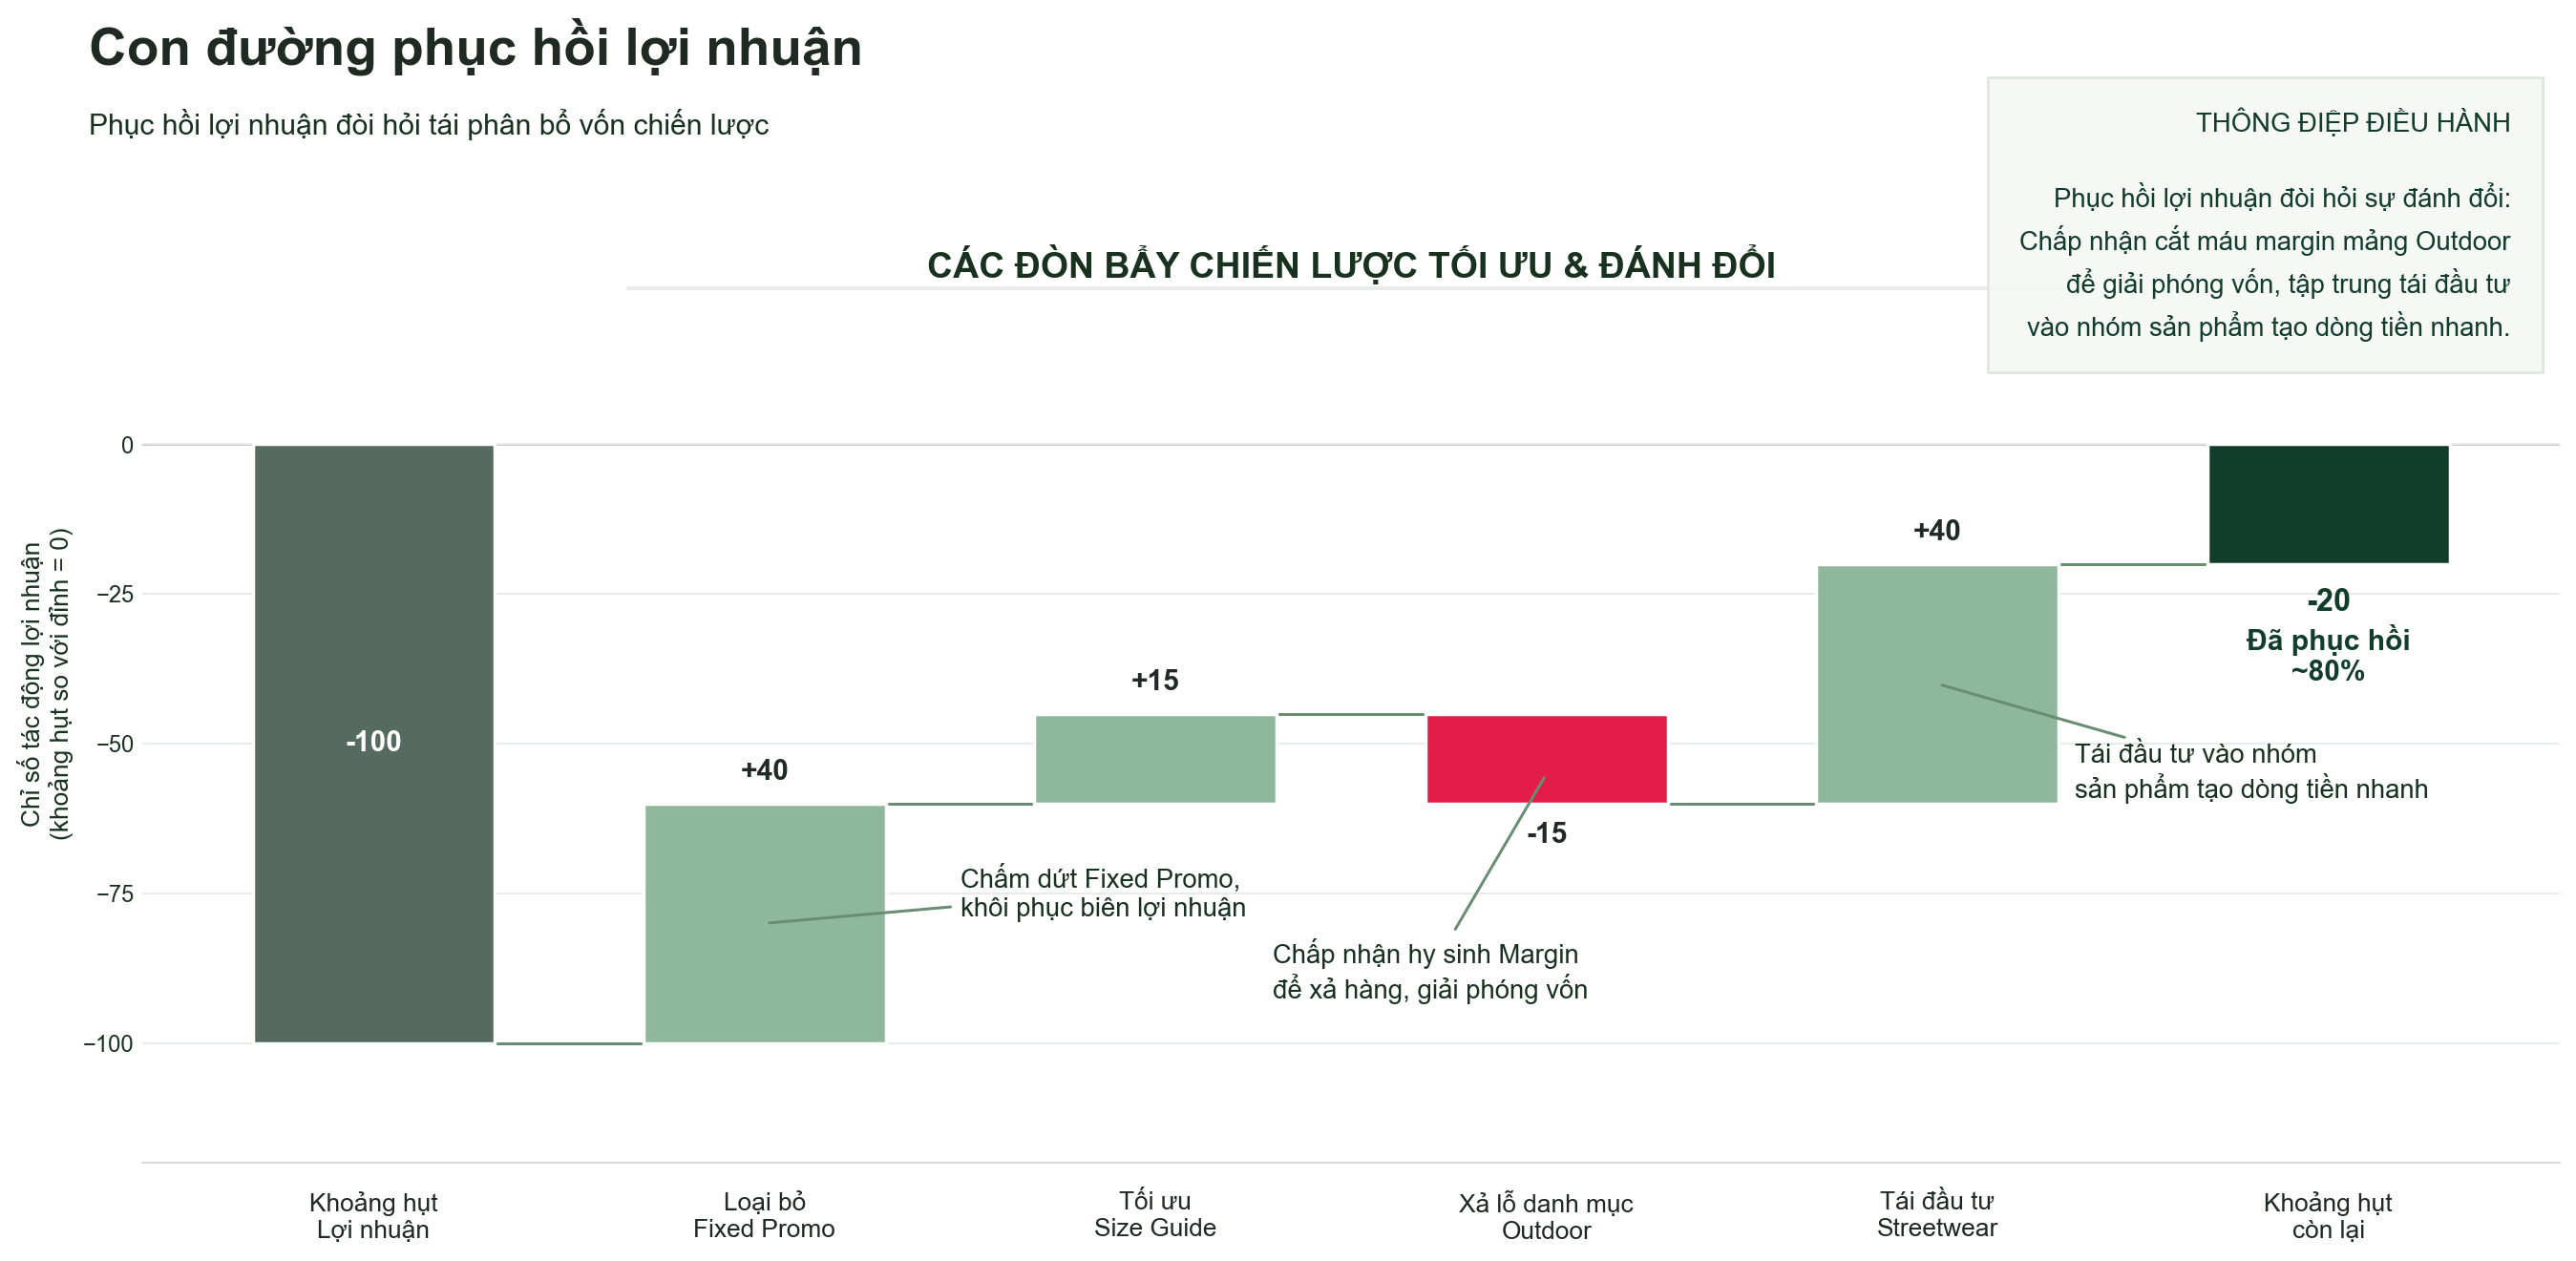

In [144]:
fig, ax = create_profit_recovery_waterfall(labels, values, contributions, final_value, colors)

png_path = OUT_DIR / "profit_recovery_waterfall.png"
svg_path = OUT_DIR / "profit_recovery_waterfall.svg"
fig.savefig(png_path, bbox_inches="tight", facecolor="white")
fig.savefig(svg_path, bbox_inches="tight", facecolor="white")

print(png_path)
print(svg_path)
plt.show()